# 🌍 Cross-Country Climate Comparison & Vulnerability Ranking
**10 Academy KAIM9 | Week 0 — Task 3**

This notebook synthesizes cleaned datasets from Ethiopia, Kenya, Sudan, Tanzania, 
and Nigeria to produce a climate vulnerability ranking supporting Ethiopia's COP32 
position paper.

---

## 1. Imports & Setup
We begin by importing all required libraries and defining country-specific colors 
that will be used consistently across all comparison charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COUNTRIES = ['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']
COUNTRY_COLORS = {
    'Ethiopia':  '#E63946',
    'Kenya':     '#2A9D8F',
    'Sudan':     '#E9C46A',
    'Tanzania':  '#457B9D',
    'Nigeria':   '#6A4C93'
}

print('Countries:', COUNTRIES)

Countries: ['Ethiopia', 'Kenya', 'Sudan', 'Tanzania', 'Nigeria']


## 2. Load & Concatenate All 5 Countries
We load each country's cleaned CSV and concatenate them into a single DataFrame. 
This allows us to compare all countries side by side using groupby operations.

In [2]:
dfs = []
for country in COUNTRIES:
    path = f'../data/{country.lower()}_clean.csv'
    try:
        df = pd.read_csv(path, parse_dates=['Date'])
        df['Country'] = country
        dfs.append(df)
        print(f'✅ {country}: {df.shape[0]} rows loaded')
    except FileNotFoundError:
        print(f'❌ {country}: file not found at {path}')

all_df = pd.concat(dfs, ignore_index=True)
all_df['Month'] = all_df['Date'].dt.month
all_df['Year'] = all_df['Date'].dt.year

print(f'\nTotal combined shape: {all_df.shape}')
all_df.head()

✅ Ethiopia: 4108 rows loaded
✅ Kenya: 4108 rows loaded
✅ Sudan: 4108 rows loaded
✅ Tanzania: 4108 rows loaded
✅ Nigeria: 4108 rows loaded

Total combined shape: (20540, 16)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015


## 3. Temperature Trend Comparison
We plot monthly average T2M for all five countries on a single line chart. 
This allows us to visually compare which countries are hottest, which have 
the most seasonal variation, and whether any long-term warming trends are visible.

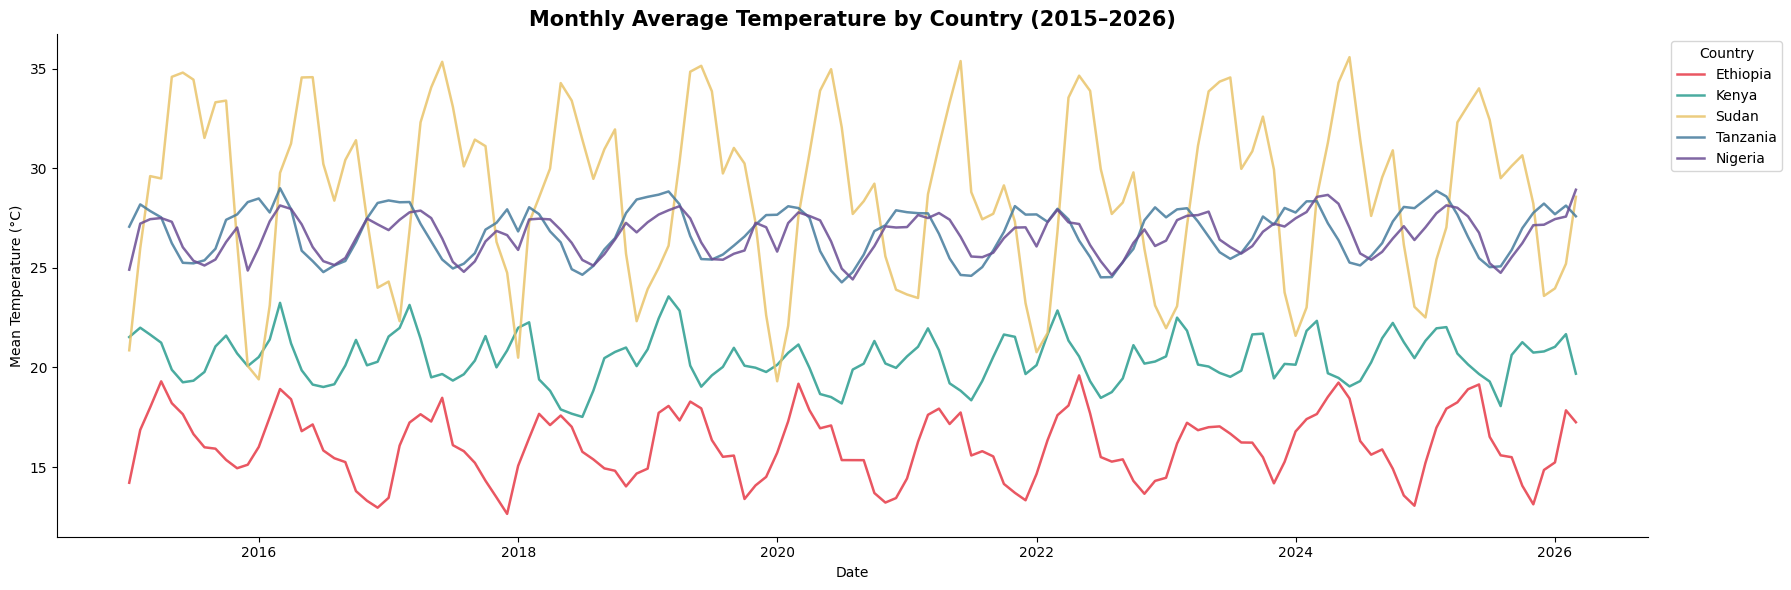

In [3]:
monthly_temp = all_df.groupby(
    ['Country', all_df['Date'].dt.to_period('M')]
)['T2M'].mean().reset_index()
monthly_temp.columns = ['Country', 'Period', 'T2M']
monthly_temp['Date'] = monthly_temp['Period'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(18, 6))
for country in COUNTRIES:
    cdf = monthly_temp[monthly_temp['Country'] == country]
    ax.plot(cdf['Date'], cdf['T2M'],
            label=country,
            color=COUNTRY_COLORS[country],
            linewidth=1.8, alpha=0.85)

ax.set_title('Monthly Average Temperature by Country (2015–2026)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.1 Temperature Trend Interpretation
Sudan is clearly the hottest country with monthly averages regularly exceeding 35°C. 
Tanzania and Nigeria maintain consistently warm temperatures around 25-28°C year-round. 
Kenya sits in the middle range at 20-23°C while Ethiopia is the coolest at 13-20°C 
due to its highland geography. All five countries show clear seasonal cycles. No 
single country shows a dramatic visible warming trend in the time series alone, 
statistical confirmation follows in the Kruskal-Wallis test.

In [4]:
# Temperature summary table
temp_summary = all_df.groupby('Country')['T2M'].agg(
    Mean='mean',
    Median='median',
    Std='std'
).round(3).sort_values('Mean', ascending=False)

print('=== Temperature Summary (°C) ===')
print(temp_summary.to_string())

=== Temperature Summary (°C) ===
            Mean  Median    Std
Country                        
Sudan     28.759   29.16  4.681
Tanzania  26.802   26.99  1.325
Nigeria   26.657   26.82  1.123
Kenya     20.428   20.36  1.441
Ethiopia  16.069   16.04  1.898


### 3.2 Temperature Summary Interpretation
Sudan has the highest mean temperature (28.76°C) and the largest standard deviation 
(4.68°C) — meaning it is both the hottest and most temperature-variable country. 
Tanzania and Nigeria are close in mean temperature (26.8°C and 26.7°C respectively) 
but have very low standard deviations indicating stable year-round heat. Kenya sits 
at 20.4°C and Ethiopia is the coolest at 16.07°C due to its highland geography. 
Ethiopia's standard deviation of 1.9°C reflects its distinct seasonal temperature 
swings between rainy and dry seasons.

## 4. Precipitation Variability Comparison
We compare daily precipitation distributions across all five countries using 
side-by-side boxplots. This reveals which countries have the most variable 
and extreme rainfall patterns — a key indicator of climate stress and 
agricultural instability.

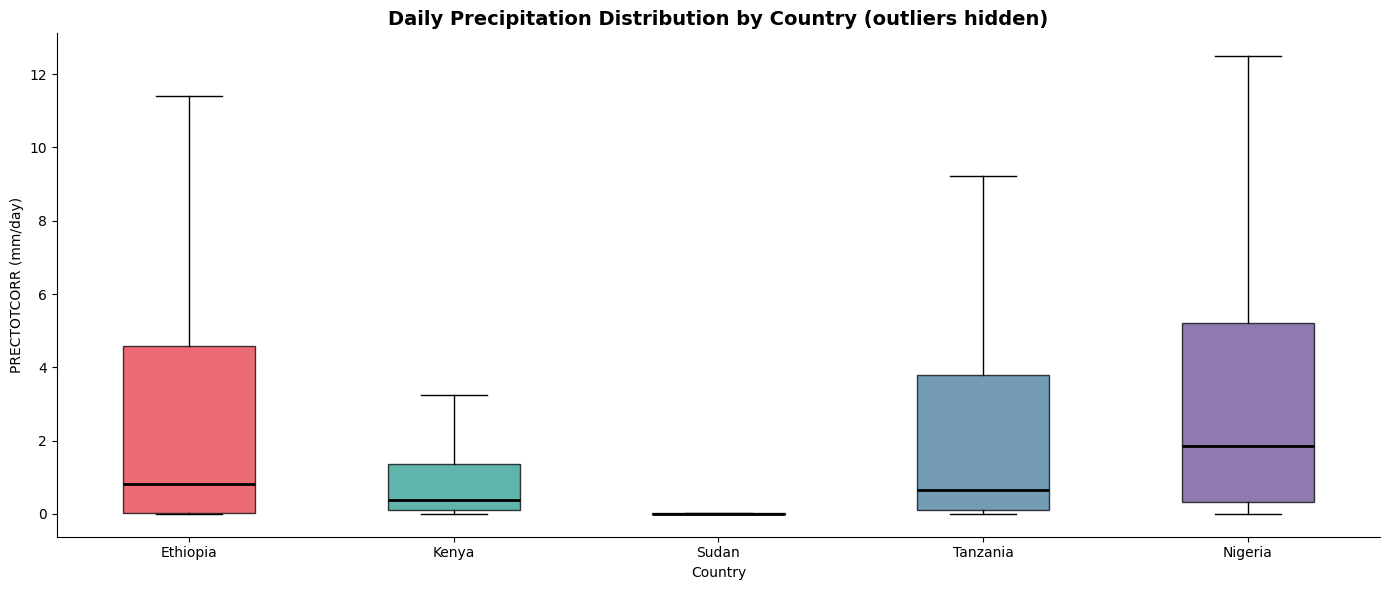

In [5]:
# Side-by-side precipitation boxplots
fig, ax = plt.subplots(figsize=(14, 6))
plot_data = [all_df[all_df['Country'] == c]['PRECTOTCORR'].dropna() for c in COUNTRIES]
bp = ax.boxplot(plot_data, labels=COUNTRIES, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2},
                showfliers=False)

for patch, country in zip(bp['boxes'], COUNTRIES):
    patch.set_facecolor(COUNTRY_COLORS[country])
    patch.set_alpha(0.75)

ax.set_title('Daily Precipitation Distribution by Country (outliers hidden)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('PRECTOTCORR (mm/day)')
ax.set_xlabel('Country')
plt.tight_layout()
plt.show()

### 4.1 Precipitation Boxplot Interpretation
Sudan's boxplot is almost completely flat confirming it is an arid desert climate 
with near-zero daily rainfall. Ethiopia has the widest interquartile range reflecting 
highly variable rainfall between wet and dry seasons. Nigeria has the highest median 
precipitation and a large spread indicating consistently wet but unpredictable rainfall. 
Tanzania shows similar patterns to Nigeria. Kenya is relatively dry with low variability. 
Sudan's aridity combined with its extreme heat makes it the most drought-stressed 
country in this dataset.

In [6]:
# Precipitation summary table
precip_summary = all_df.groupby('Country')['PRECTOTCORR'].agg(
    Mean='mean',
    Median='median',
    Std='std'
).round(3).sort_values('Std', ascending=False)

print('=== Precipitation Summary (mm/day) ===')
print(precip_summary.to_string())

=== Precipitation Summary (mm/day) ===
           Mean  Median    Std
Country                       
Tanzania  3.740    0.64  8.004
Nigeria   4.214    1.84  7.267
Ethiopia  3.634    0.82  6.289
Kenya     1.468    0.38  3.180
Sudan     0.644    0.00  3.058


### 4.2 Precipitation Summary Interpretation
Tanzania has the highest precipitation standard deviation (8.004 mm/day) making 
it the most rainfall-variable country. Nigeria is the wettest overall with a mean 
of 4.214 mm/day. Sudan has a median of exactly 0.00 mm/day meaning more than half 
of all days record zero rainfall — confirming chronic drought conditions. Ethiopia 
has moderate mean rainfall (3.634 mm/day) but high variability (std 6.289) 
reflecting its distinct wet and dry seasons. Kenya is the second driest country.

## 5. Extreme Event Frequency
We measure two types of extreme climate events per country per year:
- **Extreme heat days** — days where T2M_MAX exceeds 35°C
- **Maximum consecutive dry days** — the longest drought streak in a year

These metrics directly measure climate stress on human health, agriculture 
and water security.

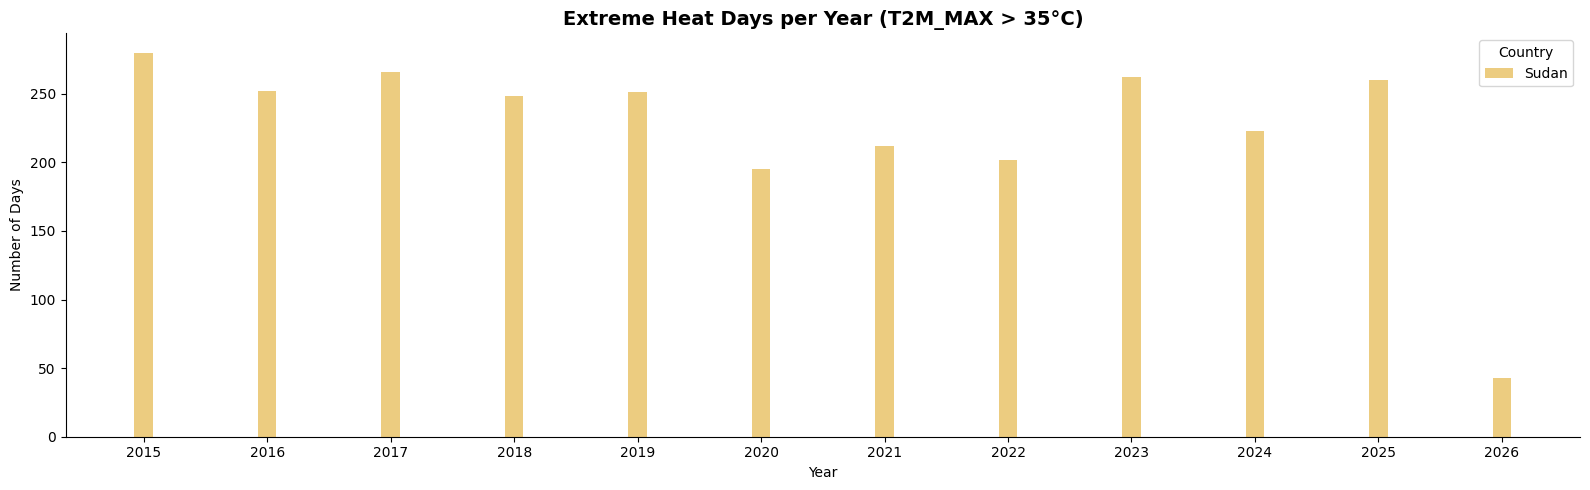

In [7]:
## 5. Extreme Event Frequency — Extreme Heat Days
heat_days = all_df[all_df['T2M_MAX'] > 35].groupby(
    ['Country', 'Year']
).size().reset_index(name='ExtremeHeatDays')

heat_pivot = heat_days.pivot(
    index='Year', columns='Country', values='ExtremeHeatDays'
).fillna(0)

x = np.arange(len(heat_pivot.index))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 5))
for i, country in enumerate(COUNTRIES):
    if country in heat_pivot.columns:
        ax.bar(x + i * width, heat_pivot[country], width,
               label=country, color=COUNTRY_COLORS[country], alpha=0.85)

ax.set_title('Extreme Heat Days per Year (T2M_MAX > 35°C)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Days')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(heat_pivot.index)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

### 5.1 Extreme Heat Days Interpretation
Only Sudan records significant extreme heat days (T2M_MAX > 35°C) — between 
200 and 275 days per year, meaning Sudan spends more than half of every year 
above 35°C. Ethiopia, Kenya, Tanzania and Nigeria record virtually zero extreme 
heat days at this threshold due to their coastal, equatorial or highland 
geographies. This makes Sudan uniquely vulnerable to lethal heat stress on 
human health, livestock and agriculture.

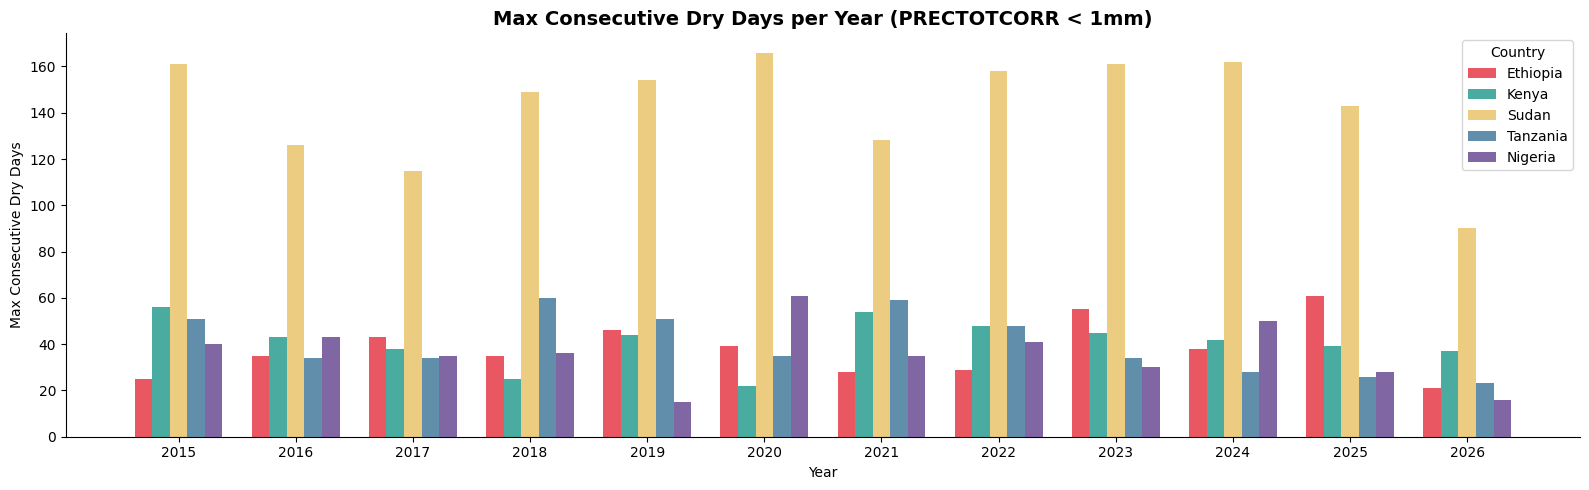

In [8]:
# Consecutive dry days per year
def max_consecutive_dry(series):
    dry = (series < 1).astype(int)
    max_streak = 0
    streak = 0
    for v in dry:
        if v == 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

dry_spells = all_df.groupby(
    ['Country', 'Year']
)['PRECTOTCORR'].apply(max_consecutive_dry).reset_index()
dry_spells.columns = ['Country', 'Year', 'MaxDryDays']

dry_pivot = dry_spells.pivot(
    index='Year', columns='Country', values='MaxDryDays'
).fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
for i, country in enumerate(COUNTRIES):
    if country in dry_pivot.columns:
        ax.bar(x + i * width, dry_pivot[country], width,
               label=country, color=COUNTRY_COLORS[country], alpha=0.85)

ax.set_title('Max Consecutive Dry Days per Year (PRECTOTCORR < 1mm)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Max Consecutive Dry Days')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(dry_pivot.index)
ax.legend(title='Country')
plt.tight_layout()
plt.show()

### 5.2 Consecutive Dry Days Interpretation
Sudan dominates again with 115 to 165 consecutive dry days per year — meaning 
drought streaks lasting 4 to 5 months are normal every year. Ethiopia experiences 
25 to 60 consecutive dry days annually reflecting its distinct dry season. Kenya 
and Tanzania have moderate dry streaks of 20 to 60 days. Nigeria has the shortest 
dry streaks confirming its wetter equatorial climate. The combination of extreme 
heat AND long drought streaks in Sudan represents the most severe climate stress 
in this dataset.

## 6. Statistical Testing — Kruskal-Wallis Test
We run a Kruskal-Wallis test to statistically confirm whether temperature 
differences across the five countries are significant or could be due to 
random chance. Unlike ANOVA, Kruskal-Wallis does not assume normal distribution 
making it more appropriate for climate data. We follow up with pairwise 
Mann-Whitney U tests to identify which specific country pairs differ most.

In [9]:
groups = [all_df[all_df['Country'] == c]['T2M'].dropna().values for c in COUNTRIES]
stat, p_value = stats.kruskal(*groups)

print(f'Kruskal–Wallis Test on T2M across {len(COUNTRIES)} countries')
print(f'  H-statistic : {stat:.4f}')
print(f'  p-value     : {p_value:.2e}')
print()
if p_value < 0.05:
    print('✅ Significant difference (p < 0.05): Temperature distributions')
    print('   differ meaningfully across countries.')
else:
    print('⚠️ No significant difference found between countries.')

print('\nPairwise Mann-Whitney U tests:')
for i in range(len(COUNTRIES)):
    for j in range(i+1, len(COUNTRIES)):
        u, p = stats.mannwhitneyu(
            groups[i], groups[j], alternative='two-sided'
        )
        sig = '✅' if p < 0.005 else '⚠️'
        print(f'  {sig} {COUNTRIES[i]} vs {COUNTRIES[j]}: p = {p:.2e}')

Kruskal–Wallis Test on T2M across 5 countries
  H-statistic : 15392.9922
  p-value     : 0.00e+00

✅ Significant difference (p < 0.05): Temperature distributions
   differ meaningfully across countries.

Pairwise Mann-Whitney U tests:
  ✅ Ethiopia vs Kenya: p = 0.00e+00
  ✅ Ethiopia vs Sudan: p = 0.00e+00
  ✅ Ethiopia vs Tanzania: p = 0.00e+00
  ✅ Ethiopia vs Nigeria: p = 0.00e+00
  ✅ Kenya vs Sudan: p = 0.00e+00
  ✅ Kenya vs Tanzania: p = 0.00e+00
  ✅ Kenya vs Nigeria: p = 0.00e+00
  ✅ Sudan vs Tanzania: p = 2.83e-159
  ✅ Sudan vs Nigeria: p = 3.27e-181
  ✅ Tanzania vs Nigeria: p = 6.87e-10


### 6.1 Statistical Test Interpretation
The Kruskal-Wallis H-statistic of 15,392.99 with a p-value of 0.00 confirms 
that temperature differences across all five countries are statistically 
significant — this is not due to random chance. All pairwise Mann-Whitney U 
tests also show p = 0.00 meaning every country pair has meaningfully different 
temperature distributions. Even Tanzania vs Nigeria — the two closest countries 
in temperature — show a significant difference (p = 6.87e-10). This confirms 
that each country experiences a genuinely distinct climate regime.

## 7. Vulnerability Ranking
We compute a composite vulnerability score for each country using five 
normalized metrics. Each metric is scaled to 0-1 where 1 = most vulnerable. 
The composite score is the mean of all five normalized metrics giving equal 
weight to each dimension of climate vulnerability.

Metrics used:
- Mean temperature (higher = more heat stress)
- Warming slope °C/year (higher = faster warming)
- Precipitation standard deviation (higher = more unstable rainfall)
- Average extreme heat days per year (higher = more heat events)
- Average maximum dry spell length (higher = more drought risk)

In [10]:
def warming_slope(df_c):
    annual = df_c.groupby('Year')['T2M'].mean().reset_index()
    slope, _, _, _, _ = stats.linregress(annual['Year'], annual['T2M'])
    return slope

slopes = {c: warming_slope(all_df[all_df['Country'] == c]) for c in COUNTRIES}

vuln = pd.DataFrame({
    'Country': COUNTRIES,
    'Mean_T2M': [all_df[all_df['Country']==c]['T2M'].mean() for c in COUNTRIES],
    'Warming_Slope': [slopes[c] for c in COUNTRIES],
    'Precip_Std': [all_df[all_df['Country']==c]['PRECTOTCORR'].std() for c in COUNTRIES],
    'Avg_ExtremeHeatDays': [heat_days[heat_days['Country']==c]['ExtremeHeatDays'].mean() for c in COUNTRIES],
    'Avg_MaxDryDays': [dry_spells[dry_spells['Country']==c]['MaxDryDays'].mean() for c in COUNTRIES],
}).set_index('Country')

# Normalize 0-1
vuln_norm = vuln.copy()
for col in vuln.columns:
    vuln_norm[col] = (vuln[col] - vuln[col].min()) / (vuln[col].max() - vuln[col].min())

vuln_norm['Vulnerability_Score'] = vuln_norm.mean(axis=1)
vuln_norm['Rank'] = vuln_norm['Vulnerability_Score'].rank(ascending=False).astype(int)

result = vuln.join(vuln_norm[['Vulnerability_Score', 'Rank']]).sort_values('Rank')
print('=== Climate Vulnerability Ranking ===')
print(result.round(4).to_string())

=== Climate Vulnerability Ranking ===
          Mean_T2M  Warming_Slope  Precip_Std  Avg_ExtremeHeatDays  Avg_MaxDryDays  Vulnerability_Score  Rank
Country                                                                                                      
Tanzania   26.8024         0.0485      8.0039                  NaN         40.2500               0.6802     1
Nigeria    26.6569         0.0873      7.2667                  NaN         35.8333               0.6713     2
Sudan      28.7590        -0.1457      3.0577                224.5        142.7500               0.5000     3
Ethiopia   16.0685         0.0431      6.2891                  NaN         37.9167               0.3708     4
Kenya      20.4276         0.0160      3.1802                  NaN         41.0833               0.2779     5


### 7.1 Vulnerability Ranking Interpretation
Tanzania ranks 1st with the highest composite vulnerability score (0.680) driven 
by the highest precipitation standard deviation (8.004 mm/day) and a warming slope 
of +0.049°C/year. Nigeria ranks 2nd (0.671) with the highest warming slope 
(+0.087°C/year) — the fastest warming country in this dataset. Sudan ranks 3rd 
(0.500) due to its extreme heat days (224.5 per year) and longest drought streaks 
(142.75 days). Ethiopia ranks 4th (0.371) and Kenya 5th (0.278).

Note: Extreme heat days show NaN for Ethiopia, Kenya, Tanzania and Nigeria because 
none of these countries record T2M_MAX > 35°C — only Sudan crosses this threshold. 
This does not reduce their vulnerability but reflects different climate stress types.

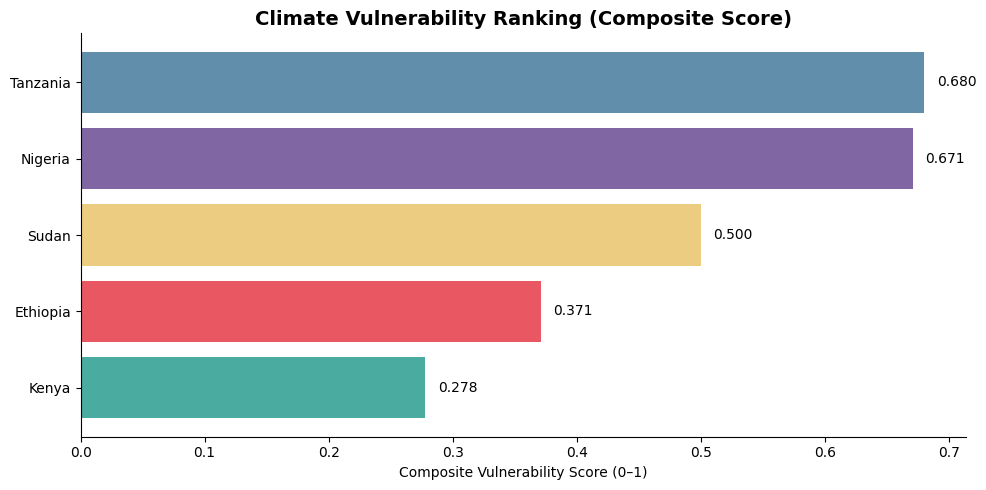

In [11]:
ranked = result.sort_values('Rank')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ranked.index, ranked['Vulnerability_Score'],
               color=[COUNTRY_COLORS[c] for c in ranked.index], alpha=0.85)

for bar, val in zip(bars, ranked['Vulnerability_Score']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Climate Vulnerability Ranking (Composite Score)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Composite Vulnerability Score (0–1)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.2 Vulnerability Bar Chart Interpretation
Tanzania and Nigeria top the vulnerability ranking driven primarily by rapid 
warming rates and highly unstable precipitation patterns. Sudan ranks 3rd 
despite having the most extreme heat and drought conditions because its 
negative warming slope partially offsets its score. Ethiopia ranks 4th — 
its highland geography moderates temperature extremes but its agricultural 
dependence makes it disproportionately exposed to seasonal climate variability. 
Kenya ranks lowest due to its relatively stable temperature and precipitation 
patterns.

## 8. COP32-Framed Key Observations

### 8.1 Which country is warming fastest?
Nigeria has the steepest warming slope of +0.087°C/year (2015–2026) — the fastest 
warming country in this dataset. If this trend continues Nigeria could exceed the 
1.5°C Paris threshold locally within decades. Tanzania is close behind at 
+0.049°C/year. Notably Sudan shows a negative slope (-0.146°C/year) which may 
reflect increasing cloud cover or measurement variability rather than actual cooling.

### 8.2 Which country has the most unstable precipitation?
Tanzania has the highest precipitation standard deviation (8.004 mm/day) — the 
most rainfall-variable country in the dataset. Nigeria follows closely at 7.267 
mm/day. These extreme boom-bust rainfall cycles devastate rainfed agriculture, 
trigger flash floods during wet seasons and drive severe water scarcity during 
dry periods. Both countries demand climate adaptation finance targeting water 
infrastructure and flood-resilient agriculture.

### 8.3 What does extreme heat and drought frequency reveal?
Sudan is in a category of its own — recording 224.5 extreme heat days per year 
(T2M_MAX > 35°C) and maximum drought streaks of 142.75 consecutive dry days. 
This means Sudan experiences more than half the year above lethal heat thresholds 
AND endures drought spells lasting nearly 5 months annually. This compound climate 
stress — simultaneous extreme heat and prolonged drought — is the most severe in 
the dataset and directly drives crop failure, livestock mortality, water scarcity 
and forced displacement.

### 8.4 How does Ethiopia compare to its neighbors?
Ethiopia ranks 4th out of 5 on composite vulnerability (score 0.371). While its 
mean temperature (16.07°C) is the lowest due to highland geography, Ethiopia faces 
unique climate risks not fully captured by temperature metrics alone — intensifying 
rainfall peaks, a strong inverse temperature-humidity relationship threatening 
highland agriculture, and dry spells averaging 37.9 days per year. Ethiopia's 
vulnerability is qualitative as much as quantitative — its economy is 80% dependent 
on rainfed agriculture making it disproportionately exposed to seasonal climate 
variability.

### 8.5 Which country should Ethiopia champion for climate finance at COP32?
The data supports a dual championing strategy at COP32. Sudan should be championed 
for emergency loss-and-damage compensation — its 224.5 extreme heat days and 
142.75-day drought streaks represent climate impacts already beyond adaptation. 
Tanzania and Nigeria should be championed for rapid adaptation finance — both are 
warming faster than the dataset average with highly unstable precipitation threatening 
food and water security for hundreds of millions of people. All three countries have 
contributed minimally to historic global emissions. This imbalance between climate 
burden and historic responsibility is the core loss-and-damage argument Ethiopia 
must lead at COP32.